<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [2]:
!pip install -q torch torchvision

In [3]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 6.9 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [6]:

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from sklearn.cluster import DBSCAN
from torchvision import transforms as T
import supervision as sv
from supervision.metrics import MeanAveragePrecision

from transformers import Sam3Processor, Sam3Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [7]:
IMAGE_PATH_target = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH_target = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"

IMAGE_PATH_reference = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426111205_0193.JPG"
LABEL_PATH_reference = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20230426111205_0193.txt"

RUMEX_CLASS_ID = 0

In [8]:
# YOLO box loader + load TARGET image & GT
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

target_image = Image.open(IMAGE_PATH_target).convert("RGB")
target_img_w, target_img_h = target_image.size
print(f"Target image size (W, H): {target_image.size}")

gt_boxes_target = load_yolo_boxes(LABEL_PATH_target, target_img_w, target_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_target)} GT box(es) on TARGET image with class id={RUMEX_CLASS_ID}.")

Target image size (W, H): (8192, 5460)
Loaded 57 GT box(es) on TARGET image with class id=0.


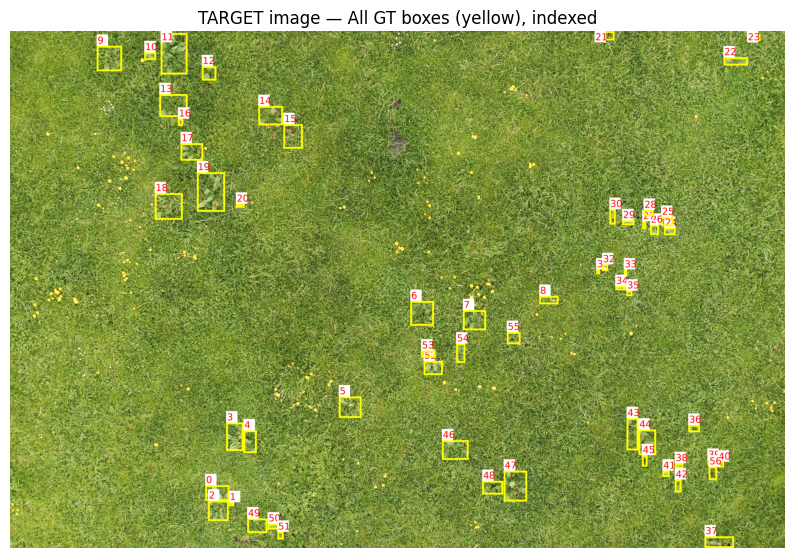

In [9]:
# Visualize TARGET image GT boxes (indexed)
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

def draw_indexed_boxes(base_image, boxes, color=(255, 255, 0)):
    preview = base_image.copy()
    draw = ImageDraw.Draw(preview)
    for i, (x0, y0, x1, y1) in enumerate(boxes):
        draw.rectangle([x0, y0, x1, y1], outline=color, width=20)
        text_x, text_y = int(x0), max(0, int(y0) - 120)
        draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
        draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)
    return preview

target_gt_preview = draw_indexed_boxes(target_image, gt_boxes_target)
plt.figure(figsize=(10, 8))
plt.imshow(target_gt_preview)
plt.title("TARGET image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

In [10]:
#  Load REFERENCE image + GT boxes
reference_image = Image.open(IMAGE_PATH_reference).convert("RGB")
ref_img_w, ref_img_h = reference_image.size
print(f"Reference image size (W, H): {reference_image.size}")

gt_boxes_reference = load_yolo_boxes(LABEL_PATH_reference, ref_img_w, ref_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_reference)} GT box(es) on REFERENCE image with class id={RUMEX_CLASS_ID}.")

Reference image size (W, H): (8192, 5460)
Loaded 48 GT box(es) on REFERENCE image with class id=0.


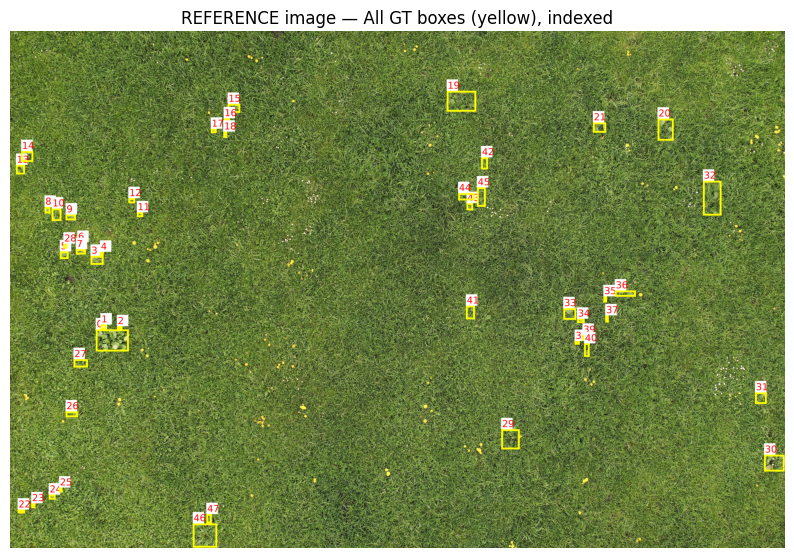

In [11]:
#  Visualize REFERENCE image GT boxes (indexed)
ref_gt_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
plt.figure(figsize=(10, 8))
plt.imshow(ref_gt_preview)
plt.title("REFERENCE image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

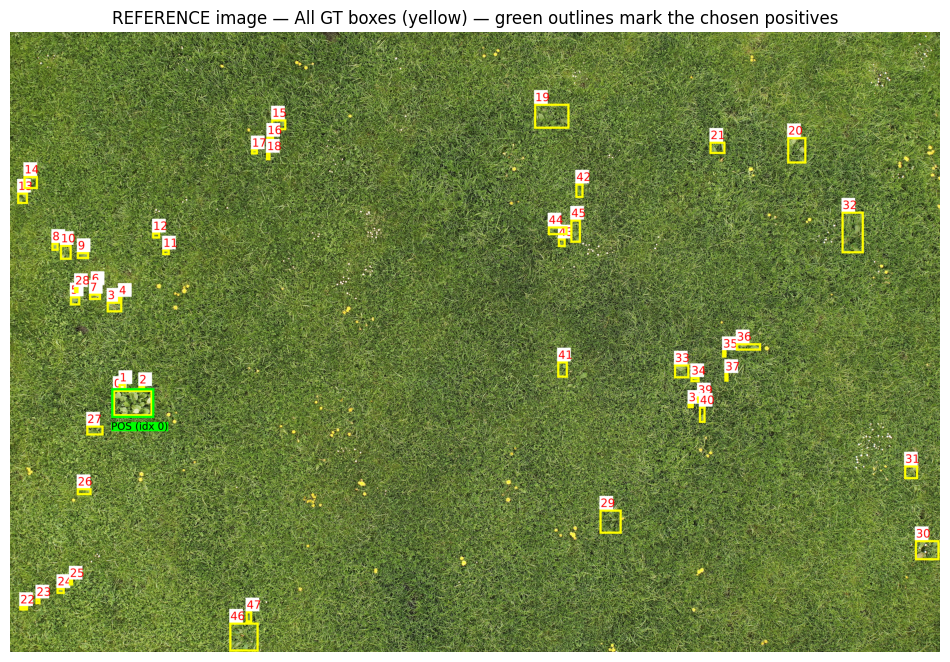

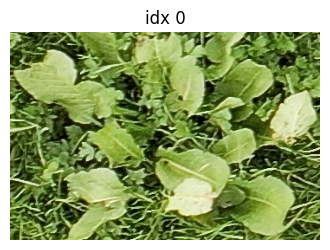

In [12]:
# Choose ONE positive exemplar by index (from REFERENCE image GT),
# crop it, and highlight against all reference GT boxes

positive_indices = [0]

exemplar_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
draw = ImageDraw.Draw(exemplar_preview)
HIGHLIGHT_PAD = 15
label_font = ImageFont.truetype(font_path, 90)

exemplar_crops = []
for positive_index in positive_indices:
    ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes_reference[positive_index]
    draw.rectangle(
        [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
        outline=(0, 255, 0), width=20,
    )
    label_text = f"POS (idx {positive_index})"
    label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
    text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
    draw.rectangle(text_bbox, fill=(0, 255, 0))
    draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

    PAD = 4
    crop = reference_image.crop((
        max(0, ex_x0 - PAD), max(0, ex_y0 - PAD),
        min(reference_image.width, ex_x1 + PAD), min(reference_image.height, ex_y1 + PAD),
    ))
    exemplar_crops.append(crop)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("REFERENCE image — All GT boxes (yellow) — green outlines mark the chosen positives")
plt.show()

fig, axes = plt.subplots(1, len(exemplar_crops), figsize=(4 * len(exemplar_crops), 4))
if len(exemplar_crops) == 1:
    axes = [axes]
for ax, crop, idx in zip(axes, exemplar_crops, positive_indices):
    ax.imshow(crop)
    ax.set_title(f"idx {idx}")
    ax.axis("off")
plt.show()

In [13]:
# ============================================================
# CELL 8 — DINOv2 model load (torch.hub, gives get_intermediate_layers)
# ============================================================
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14').to(DEVICE).eval()

PATCH_SIZE = 14  # dinov2_vitb14 patch size

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
dino_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f"Loaded dinov2_vitb14 on {DEVICE}, patch_size={PATCH_SIZE}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded facebook/dinov2-base on cuda, patch_size=14


In [14]:
# Patch feature extraction function
@torch.no_grad()
def extract_patch_features(image_pil, max_size=896):
    '''
    image_pil: a PIL image (RGB)
    max_size: the longest side is resized down to at most this many pixels,
              to keep memory/speed reasonable. Increase for more detail on
              small objects, decrease if you run out of GPU memory.
    Returns: (feats [N, C] tensor, coords [N, 2] numpy array of (x, y) in ORIGINAL pixels)
    '''
    orig_w, orig_h = image_pil.size
    scale = min(1.0, max_size / max(orig_w, orig_h))
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    # Round down to the nearest multiple of the patch size (DINOv2 requirement)
    new_w = max(PATCH_SIZE, (new_w // PATCH_SIZE) * PATCH_SIZE)
    new_h = max(PATCH_SIZE, (new_h // PATCH_SIZE) * PATCH_SIZE)

    resized = image_pil.resize((new_w, new_h))
    tensor = dino_transform(resized).unsqueeze(0).to(DEVICE)
    # get_intermediate_layers with reshape=True gives us a spatial feature MAP
    # instead of a flat list, i.e. shape [1, C, H_patches, W_patches]
    feat_map = dino_model.get_intermediate_layers(tensor, n=1, reshape=True)[0]
    feat_map = feat_map.squeeze(0)  # [C, Hp, Wp]
    C, Hp, Wp = feat_map.shape

    feats = feat_map.permute(1, 2, 0).reshape(-1, C)  # [Hp*Wp, C]
    feats = F.normalize(feats, dim=-1)  # so dot product = cosine similarity later

    # Build the pixel coordinate (in the ORIGINAL, un-resized image) that each
    # patch corresponds to, so matches can be reported in real pixel positions.
    coords = np.zeros((Hp * Wp, 2), dtype=np.float32)
    idx = 0
    for yy in range(Hp):
        for xx in range(Wp):
            px = (xx + 0.5) * (orig_w / Wp)
            py = (yy + 0.5) * (orig_h / Hp)
            coords[idx] = [px, py]
            idx += 1

    return feats.cpu(), coords

print("Feature extraction function ready.")

Feature extraction function ready.


In [15]:
# Tiled feature extraction (for large drone images)
TILE_SIZE = 896          # size (px) of each tile fed to DINOv2
TILE_OVERLAP = 0.2       # fraction of overlap between neighboring tiles

def extract_tiled_features(image_pil, tile_size=TILE_SIZE, overlap=TILE_OVERLAP, max_size=896):
    '''
    Splits a large image into overlapping tiles, runs extract_patch_features on
    each tile, then stitches the per-tile (feats, coords) into ONE set of
    features/coordinates for the whole image. Coords are shifted into the
    ORIGINAL image's pixel space as we go, so no separate merge step is needed.
    '''
    W, H = image_pil.size
    stride = max(1, int(tile_size * (1 - overlap)))

    xs = list(range(0, max(W - tile_size, 0) + 1, stride)) or [0]
    ys = list(range(0, max(H - tile_size, 0) + 1, stride)) or [0]
    if xs[-1] + tile_size < W:
        xs.append(max(0, W - tile_size))
    if ys[-1] + tile_size < H:
        ys.append(max(0, H - tile_size))

    all_feats, all_coords = [], []
    for y0 in ys:
        for x0 in xs:
            x1, y1 = min(x0 + tile_size, W), min(y0 + tile_size, H)
            tile = image_pil.crop((x0, y0, x1, y1))

            tile_feats, tile_coords = extract_patch_features(tile, max_size=max_size)
            tile_coords = tile_coords + np.array([x0, y0], dtype=np.float32)  # shift into full-image coords

            all_feats.append(tile_feats)
            all_coords.append(tile_coords)

    feats = torch.cat(all_feats, dim=0)
    coords = np.concatenate(all_coords, axis=0)
    return feats, coords

print(f"Tiled feature extraction ready (tile_size={TILE_SIZE}px, overlap={TILE_OVERLAP:.0%}).")

Tiled feature extraction function ready.


In [16]:
# Multi-scale features for Image B (this is where we search)
SEARCH_SCALES = [1.0, 0.5]   # fractions of the ORIGINAL image size to search at
                              # 1.0 catches large objects, 0.5 catches small/far ones

image_B = target_image  # alias: this is the image we are searching for matches in

def extract_multiscale_features(image_pil, scales=SEARCH_SCALES, tile_size=TILE_SIZE, overlap=TILE_OVERLAP):
    '''
    Runs tiled feature extraction at several image scales and concatenates every
    scale's (feats, coords) together. Coordinates from every scale are rescaled
    back into ORIGINAL image pixel units, so downstream matching/clustering
    code never needs to know which scale a match came from.
    '''
    orig_w, orig_h = image_pil.size
    all_feats, all_coords = [], []

    for s in scales:
        scaled_w, scaled_h = max(1, int(orig_w * s)), max(1, int(orig_h * s))
        scaled_img = image_pil.resize((scaled_w, scaled_h), Image.BICUBIC)

        feats, coords = extract_tiled_features(scaled_img, tile_size=tile_size, overlap=overlap)
        coords = coords / s  # map coords back to ORIGINAL image pixel space

        all_feats.append(feats)
        all_coords.append(coords)

    feats = torch.cat(all_feats, dim=0)
    coords = np.concatenate(all_coords, axis=0)
    return feats, coords

# Reference exemplar(s): small crop(s), so no tiling needed — extract directly
# and pool all exemplars' patch tokens into one bank to match against.
ref_feats_list, ref_coords_list = [], []
for crop in exemplar_crops:
    feats, coords = extract_patch_features(crop, max_size=max(crop.size))
    ref_feats_list.append(feats)
    ref_coords_list.append(coords)
ref_feats = torch.cat(ref_feats_list, dim=0)
ref_feats = F.normalize(ref_feats, dim=-1)

# TARGET image (image_B) features, searched at multiple scales:
tgt_feats, tgt_coords = extract_multiscale_features(image_B)
tgt_feats = F.normalize(tgt_feats, dim=-1)

print(f"Reference exemplar patch tokens: {ref_feats.shape[0]}")
print(f"Target image (multi-scale) patch tokens: {tgt_feats.shape[0]}")

In [17]:
#  Bidirectional (mutual nearest-neighbor) matching
SIMILARITY_THRESHOLD = 0.55  # raise for stricter/fewer matches, lower for more/looser matches

def bidirectional_match(ref_feats, tgt_feats, threshold):
    # cosine similarity matrix: [N_ref, N_tgt], since both are L2-normalized
    sim = ref_feats @ tgt_feats.T
    forward_best = sim.argmax(dim=1)   # for each ref patch: best target patch
    reverse_best = sim.argmax(dim=0)   # for each target patch: best ref patch

    kept_target_indices = []
    kept_scores = []
    for i in range(ref_feats.shape[0]):
        j = forward_best[i].item()
        # keep only if the match is mutual (agrees in both directions)
        if reverse_best[j].item() == i:
            score = sim[i, j].item()
            if score > threshold:
                kept_target_indices.append(j)
                kept_scores.append(score)
    return kept_target_indices, kept_scores

matched_idx, matched_point_scores = bidirectional_match(ref_feats, tgt_feats, SIMILARITY_THRESHOLD)
matched_points = tgt_coords[matched_idx]          # pixel coordinates in Image B
matched_point_scores = np.array(matched_point_scores, dtype=np.float32)

print(f"Found {len(matched_points)} confirmed matching points in Image B.")

Exemplar prototype bank: torch.Size([3, 768])


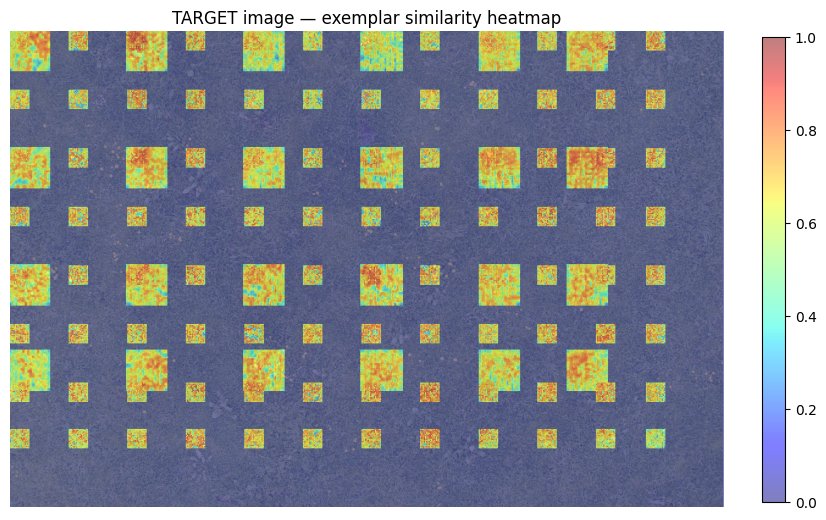

In [18]:
# Cluster matched points into candidate object boxes
CLUSTER_DISTANCE_PX = 50    # points closer than this (in pixels) are considered part of the same object
MIN_POINTS_PER_CLUSTER = 2  # ignore clusters supported by fewer points than this (likely noise)
BOX_PADDING_PX = 10         # extra margin added around each cluster's box

def points_to_boxes(points, point_scores, eps=CLUSTER_DISTANCE_PX, min_samples=MIN_POINTS_PER_CLUSTER, pad=BOX_PADDING_PX):
    '''
    Returns (boxes_xyxy, scores) — one box per cluster, and a confidence score
    per box (the mean similarity score of the points that formed the cluster).
    '''
    if len(points) == 0:
        return [], []
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_

    boxes, scores = [], []
    for label in set(labels):
        if label == -1:  # -1 means "noise", i.e. not part of any cluster
            continue
        mask = labels == label
        cluster_pts = points[mask]
        cluster_scores = point_scores[mask]

        x1, y1 = cluster_pts.min(axis=0) - pad
        x2, y2 = cluster_pts.max(axis=0) + pad
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = min(image_B.width, x2); y2 = min(image_B.height, y2)

        boxes.append([float(x1), float(y1), float(x2), float(y2)])
        scores.append(float(cluster_scores.mean()))
    return boxes, scores

candidate_boxes_xyxy, candidate_scores = points_to_boxes(matched_points, matched_point_scores)
print(f"Proposed {len(candidate_boxes_xyxy)} candidate object box(es) (x1,y1,x2,y2):")
for b, s in zip(candidate_boxes_xyxy, candidate_scores):
    print("  ", [round(v, 1) for v in b], f"score={s:.3f}")

# Visual check: plot the matched points and proposed boxes on Image B
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_B)
ax.scatter(matched_points[:, 0], matched_points[:, 1], c='yellow', s=10, label='matched points')
for b in candidate_boxes_xyxy:
    rect = plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
ax.set_title("Candidate object locations (before SAM3 refines them)")
ax.legend()
ax.axis("off")
plt.show()

Found 147 candidate cluster(s) before NMS.
147 candidate(s) after NMS.


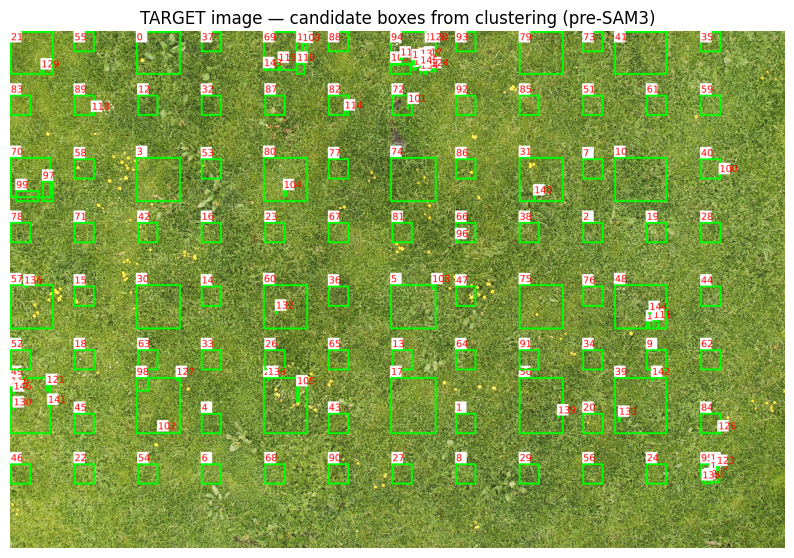

In [19]:
#  Load SAM3 (via transformers) and refine each candidate box into a mask
#  PVS (promptable visual segmentation): the SAM2-style API that takes a single box
#  (or point) and refines it into one precise mask.

from transformers import Sam3TrackerModel, Sam3TrackerProcessor

SAM3_CHECKPOINT = "facebook/sam3"  # gated checkpoint — request access on the HF model page first

sam3_tracker_model = Sam3TrackerModel.from_pretrained(SAM3_CHECKPOINT).to(DEVICE).eval()
sam3_tracker_processor = Sam3TrackerProcessor.from_pretrained(SAM3_CHECKPOINT)

final_masks, final_boxes, final_scores = [], [], []

for box, cscore in zip(candidate_boxes_xyxy, candidate_scores):
    input_boxes = [[[float(box[0]), float(box[1]), float(box[2]), float(box[3])]]]

    inputs = sam3_tracker_processor(
        images=image_B, input_boxes=input_boxes, return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = sam3_tracker_model(**inputs)

    masks = sam3_tracker_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
    )[0]  # shape: (num_boxes, num_preds_per_box, H, W)

    iou_scores = outputs.iou_scores[0, 0]
    best = int(torch.argmax(iou_scores))
    best_mask = masks[0, best].numpy().astype(bool)
    best_mask_conf = float(iou_scores[best].item())

    final_masks.append(best_mask)
    final_boxes.append(box)
    final_scores.append(best_mask_conf)  # SAM3's own mask confidence, used for filtering/mAP

print(f"SAM3 (transformers) produced {len(final_masks)} final mask(s).")

In [ ]:
# Filter by mask confidence + overlay on Image B
MASK_SCORE_THRESHOLD = 0.5  # discard predicted masks with confidence below this

def filter_by_score(masks, boxes, scores, threshold):
    keep_masks, keep_boxes, keep_scores = [], [], []
    for m, b, s in zip(masks, boxes, scores):
        s_val = float(s.item() if hasattr(s, "item") else s)
        if s_val >= threshold:
            keep_masks.append(m)
            keep_boxes.append(b)
            keep_scores.append(s_val)
    return keep_masks, keep_boxes, keep_scores

def overlay_results(image, masks, boxes, scores):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    colors = plt.colormaps.get_cmap('tab10')

    for i, (mask, box, score) in enumerate(zip(masks, boxes, scores)):
        mask_np = mask.cpu().numpy() if hasattr(mask, "cpu") else np.array(mask)
        mask_np = np.squeeze(mask_np)  # drop any leading size-1 dims, e.g. (1, H, W) -> (H, W)

        color = np.array(colors(i / max(len(masks) - 1, 1))[:3])
        colored_mask = np.zeros((*mask_np.shape, 4))
        colored_mask[mask_np > 0] = [*color, 0.5]
        ax.imshow(colored_mask)

        box_np = np.array(box)
        bx1, by1, bx2, by2 = box_np[:4]
        rect = plt.Rectangle((bx1, by1), bx2 - bx1, by2 - by1, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        ax.text(bx1, max(0, by1 - 5), f"{score:.2f}", color='white',
                 bbox=dict(facecolor=color, alpha=0.8, pad=1))

    ax.set_title(f"Found {len(masks)} matching object(s) in Image B")
    ax.axis("off")
    plt.show()

kept_masks, kept_boxes, kept_scores = filter_by_score(final_masks, final_boxes, final_scores, MASK_SCORE_THRESHOLD)
print(f"{len(kept_masks)} mask(s) above the confidence threshold of {MASK_SCORE_THRESHOLD}.")
if len(kept_masks) > 0:
    overlay_results(image_B, kept_masks, kept_boxes, kept_scores)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

Proposed 150 candidate object box(es) (x1,y1,x2,y2):
   [6155.0, 3097.0, 6175.0, 3117.0]
   [7853.0, 207.0, 7873.0, 227.0]
   [557.0, 891.0, 577.0, 911.0]
   [7965.0, 1827.0, 7985.0, 1847.0]
   [7475.0, 1841.0, 7495.0, 1861.0]
   [7307.0, 3169.0, 7369.0, 3215.0]
   [291.0, 1547.0, 353.0, 1595.0]
   [7105.0, 1981.0, 7125.0, 2001.0]
   [7699.0, 1701.0, 7719.0, 1721.0]
   [5207.0, 207.0, 5227.0, 227.0]
   [7867.0, 1785.0, 7915.0, 1805.0]
   [7363.0, 2595.0, 7383.0, 2615.0]
   [6267.0, 319.0, 6287.0, 339.0]
   [5681.0, 2469.0, 5701.0, 2489.0]
   [6715.0, 207.0, 6735.0, 241.0]
   [683.0, 1757.0, 703.0, 1777.0]
   [5373.0, 2595.0, 5407.0, 2657.0]
   [6239.0, 235.0, 6259.0, 255.0]
   [7489.0, 2609.0, 7509.0, 2629.0]
   [7559.0, 571.0, 7607.0, 605.0]
   [5165.0, 3251.0, 5185.0, 3271.0]
   [1605.0, 3837.0, 1625.0, 3857.0]
   [7321.0, 403.0, 7341.0, 423.0]
   [6309.0, 39.0, 6343.0, 87.0]
   [767.0, 3475.0, 787.0, 3495.0]
   [7651.0, 487.0, 7699.0, 591.0]
   [8077.0, 1785.0, 8097.0, 1805.0]
   [7

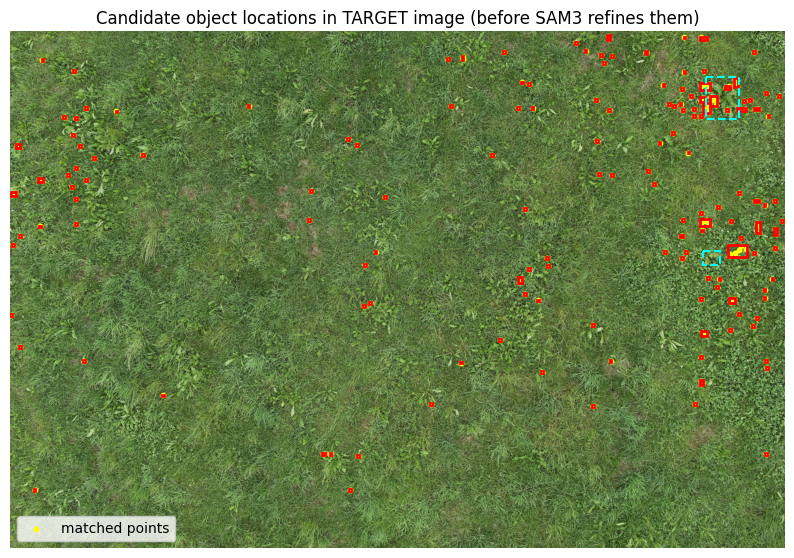

In [27]:
# Display final detections (lime) vs TARGET image GT boxes (yellow)
final_preview = image_B.convert("RGBA")

overlay_np = np.zeros((*image_B.size[::-1], 4), dtype=np.uint8)
for mask in kept_masks:
    mask_np = np.squeeze(np.array(mask)).astype(bool)
    overlay_np[mask_np] = (50, 255, 50, 100)  # lime, semi-transparent
overlay = Image.fromarray(overlay_np, "RGBA")
final_preview.paste(overlay, (0, 0), overlay)
final_preview = final_preview.convert("RGB")

draw = ImageDraw.Draw(final_preview)
for x0, y0, x1, y1 in kept_boxes:
    draw.rectangle([x0, y0, x1, y1], outline=(50, 255, 50), width=15)
for x0, y0, x1, y1 in gt_boxes_target:
    draw.rectangle([x0, y0, x1, y1], outline=(255, 255, 0), width=15)

plt.figure(figsize=(12, 10))
plt.imshow(final_preview)
plt.title("Final detections (lime) vs GT (yellow)")
plt.axis("off")
plt.show()

In [28]:
# Compute detection metrics (box-based) against TARGET image GT
pred_boxes_np = np.array(kept_boxes, dtype=np.float32) if kept_boxes else np.zeros((0, 4), dtype=np.float32)
pred_scores_np = np.array(kept_scores, dtype=np.float32) if kept_scores else np.zeros((0,), dtype=np.float32)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
)
gt_detections = sv.Detections(
    xyxy=gt_boxes_target,
    class_id=np.zeros(len(gt_boxes_target), dtype=int),
)

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes_target)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes_target)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Hugging Face SAM3 model + processor loaded.
